# method_01: LightGBM Training with CUDA 

This notebook implements a complete LightGBM training pipeline with:
- Data preprocessing using `dataset/train_tabular.csv`
- Data splitting
- CUDA-accelerated training (with automatic fallback to CPU if CUDA is unavailable)
- Checkpointing to resume training from interruptions
- Visualization of the target variable `construction_cost_per_m2_usd`

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Set random seed for reproducibility
np.random.seed(42)

# Check CUDA availability (Note: LightGBM needs to be compiled with GPU support)
# You might need to install 'lightgbm --install-option=--gpu' or specific GPU version
# Here we will set the device param, LightGBM handles the fallback if GPU not found or incompatible
device = 'cuda' # or 'gpu'
print(f"Training will attempt to use: {device}")

Training will attempt to use: cuda


In [8]:
# 1. Load Dataset
data_path = 'dataset/train_tabular.csv'
target_col = 'construction_cost_per_m2_usd'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Successfully loaded {data_path} with shape {df.shape}")
else:
    raise FileNotFoundError(f"Dataset not found at {data_path}")

# Display first few rows
display(df.head())

Successfully loaded dataset/train_tabular.csv with shape (1024, 23)


,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,...,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd
0,LP81L,Dinagat Islands,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,No,Lower-middle income,...,No,770.0,Moderate,Yes,High,Very Low,Af,sentinel_2_dinagat_islands_2019-Q3.tif,viirs_dinagat_islands_2019-Q3.tif,129.997420
1,E7EOB,29000 Nara,2024-Q2,Japan,2024,3.928801e+12,143.968241,Yes,Yes,High income,...,Yes,370.0,Moderate,Yes,Low,Very Low,Cfa,sentinel_2_29000_nara_2024-Q2.tif,viirs_29000_nara_2024-Q2.tif,1567.878774
2,WAOUA,05000 Akita,2020-Q1,Japan,2020,4.069008e+12,118.435291,Yes,No,High income,...,Yes,450.0,Moderate,Yes,Low,Very Low,Dfa,sentinel_2_05000_akita_2020-Q1.tif,viirs_05000_akita_2020-Q1.tif,2009.827701
3,2IZ5P,Cotabato,2020-Q4,Philippines,2020,2.912443e+11,119.402476,No,Yes,Lower-middle income,...,No,870.0,High,Yes,Moderate,Very Low,Af,sentinel_2_cotabato_2020-Q4.tif,viirs_cotabato_2020-Q4.tif,377.279961
4,RJ5XF,Pampanga,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,Yes,Lower-middle income,...,Yes,65.0,Moderate,Yes,Moderate,Very Low,Am,sentinel_2_pampanga_2019-Q3.tif,viirs_pampanga_2019-Q3.tif,163.905688


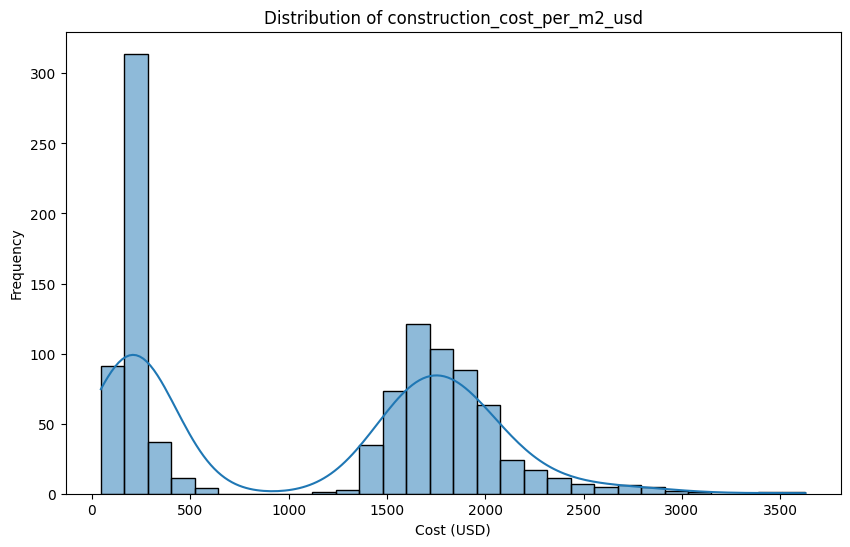

In [9]:
# 2. Visualize Target Variable
plt.figure(figsize=(10, 6))
sns.histplot(df[target_col], kde=True, bins=30)
plt.title(f'Distribution of {target_col}')
plt.xlabel('Cost (USD)')
plt.ylabel('Frequency')
plt.show()

In [10]:
# 3. Preprocessing
# Separate features and target

# Drop high-cardinality identifier columns
drop_cols = ['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name']
# Removing these cols from drop list if they don't exist, just in case
drop_cols = [c for c in drop_cols if c in df.columns]

# Feature Engineering: Extract Quarter
if 'quarter_label' in df.columns:
    # Format is 'YYYY-QX', we want the X.
    df['quarter'] = df['quarter_label'].apply(lambda x: int(x.split('-Q')[1]) if isinstance(x, str) and '-Q' in x else 0)
    drop_cols.append('quarter_label')

X = df.drop(columns=drop_cols + [target_col])
# Apply Log Transform for RMSLE optimization
y = np.log1p(df[target_col])

# Identify categorical columns
# 'object' dtype usually indicates categorical data in pandas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

# LightGBM can handle categorical features directly if they are type 'category'
for col in cat_cols:
    X[col] = X[col].astype('category')

# Split the data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, Validation set shape: {X_valid.shape}")

Categorical columns: ['geolocation_name', 'country', 'developed_country', 'landlocked', 'region_economic_classification', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone']
Training set shape: (819, 19), Validation set shape: (205, 19)


In [11]:
# 4. Training Configuration with Checkpointing

model_checkpoint_path = 'model_checkpoint.txt'

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'device': device,           # Enable CUDA/GPU
    'gpu_platform_id': 0,      # Adjust if multiple GPUs
    'gpu_device_id': 0,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'min_child_samples': 30,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'colsample_bytree': 0.8,
}

# Dataset for LightGBM
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data, categorical_feature=cat_cols)

# Check for existing checkpoint to resume
init_model = None

if os.path.exists(model_checkpoint_path):
    print(f"Found checkpoint at {model_checkpoint_path}. Resuming training...")
    init_model = model_checkpoint_path
else:
    print("No checkpoint found. Starting fresh training.")


# Parameters for training loop
num_boost_round = 1000
early_stopping_rounds = 50

# Training
print("Starting training...")
try:
    def save_model_callback(period=10):
        def callback(env):
            if env.iteration % period == 0:
                env.model.save_model(model_checkpoint_path)
        return callback

    bst = lgb.train(
        params,
        train_data,
        num_boost_round=num_boost_round,
        valid_sets=[train_data, valid_data],
        callbacks=[lgb.early_stopping(stopping_rounds=early_stopping_rounds), save_model_callback(period=50)],
        init_model=init_model # Resume if exists
    )
    
    # Save final model
    bst.save_model(model_checkpoint_path)
    print("Training completed and model saved.")

    # Reporting on Actual Values
    print(f"Best iteration: {bst.best_iteration}")
    
    # Predict on validation set
    val_preds_log = bst.predict(X_valid, num_iteration=bst.best_iteration)
    # Convert back to actual values (USD)
    val_preds_actual = np.expm1(val_preds_log)
    y_valid_actual = np.expm1(y_valid)
    
    # Calculate RMSLE using actual values
    val_rmsle = np.sqrt(mean_squared_error(np.log1p(y_valid_actual), np.log1p(val_preds_actual)))
    print(f"Validation RMSLE (calculated on actuals): {val_rmsle}")
    
    # Training scores for checking overfitting
    train_preds_log = bst.predict(X_train, num_iteration=bst.best_iteration)
    train_preds_actual = np.expm1(train_preds_log)
    y_train_actual = np.expm1(y_train)
    
    train_rmsle = np.sqrt(mean_squared_error(np.log1p(y_train_actual), np.log1p(train_preds_actual)))
    print(f"Training RMSLE (calculated on actuals): {train_rmsle}")

except Exception as e:
    if "CUDA Tree Learner was not enabled" in str(e) or "GPU Tree Learner was not enabled" in str(e):
        print(f"\nCUDA error encountered: {e}")
        print("Falling back to CPU training...")
        params['device'] = 'cpu'
        params.pop('gpu_platform_id', None)
        params.pop('gpu_device_id', None)
        
        bst = lgb.train(
            params,
            train_data,
            num_boost_round=num_boost_round,
            valid_sets=[train_data, valid_data],
            callbacks=[lgb.early_stopping(stopping_rounds=early_stopping_rounds), save_model_callback(period=50)],
            init_model=init_model 
        )
        bst.save_model(model_checkpoint_path)
        print("Training with CPU completed and model saved.")
    else:
        print(f"Training interrupted or error occurred: {e}")
        print(f"You can fix the issue and re-run this cell. It will attempt to resume from {model_checkpoint_path}")

Found checkpoint at model_checkpoint.txt. Resuming training...
Starting training...
Training interrupted or error occurred: The number of features in data (19) is not the same as it was in training data (22).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.
You can fix the issue and re-run this cell. It will attempt to resume from model_checkpoint.txt


[LightGBM] [Fatal] The number of features in data (19) is not the same as it was in training data (22).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


In [12]:
# 5. Evaluation
if 'bst' in locals():
    y_pred = bst.predict(X_valid, num_iteration=bst.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    print(f"Validation RMSE: {rmse:.4f}")
    
    # Feature Importance
    plt.figure(figsize=(10, 8))
    lgb.plot_importance(bst, max_num_features=20)
    plt.title("Feature Importance")
    plt.show()
else:
    print("Model not trained yet.")

ValueError: train and valid dataset categorical_feature do not match.